In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
x = np.tile(np.repeat(np.array([0,1]),100),20)

In [10]:
T_dev_taud = 1/26.6
diff_a = np.array([1, -1])
diff_b = np.array([0, np.exp(-T_dev_taud)])
y_diff = np.zeros_like(x)
for i in range(1,len(y_diff)):
    y_diff[i] = x[i]*diff_a[0] + x[i-1]*diff_a[1] + y_diff[i-1]*diff_b[1]

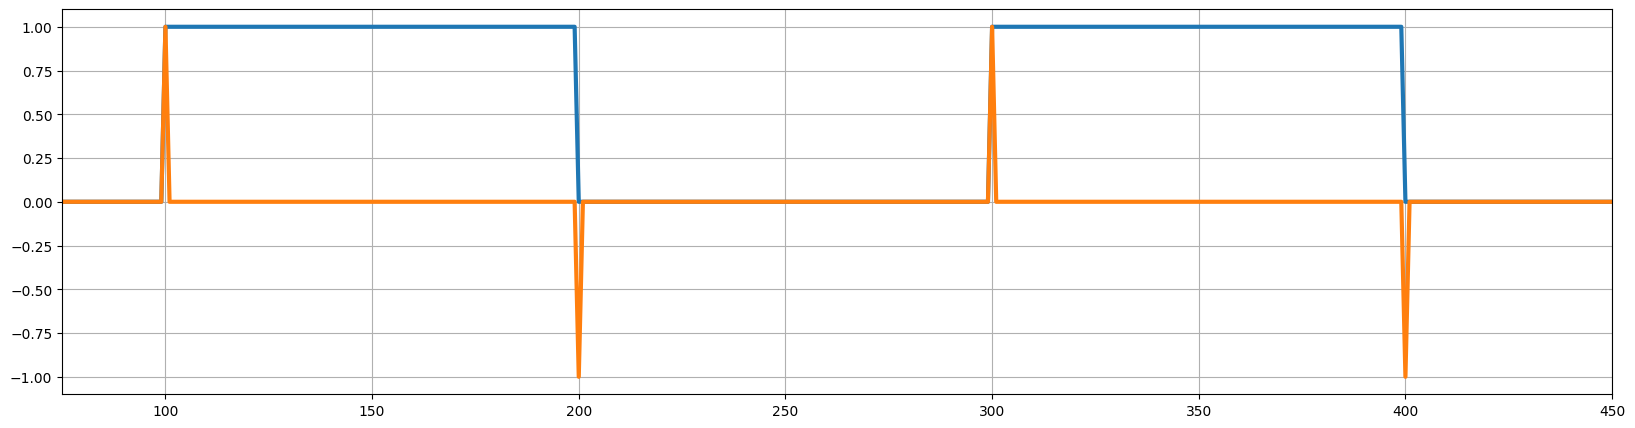

In [11]:
plt.figure(figsize=(20,5))
plt.plot(x, linewidth=3)
plt.plot(y_diff, linewidth=3)
plt.xlim(75,450)
plt.grid(1)

In [12]:
T_dev_taui = 1/1.46
int_a = np.zeros(7)
for i in range(1,len(int_a)):
    int_a[i] = np.exp(-i*T_dev_taui)*(np.exp(T_dev_taui)-1)
out = np.zeros(len(x))
y_int = np.zeros(len(x))
for i in range(6,len(y_int)):
    y_int[i] = x[i-1]*int_a[1] + x[i-2]*int_a[2] + x[i-3]*int_a[3] + x[i-4]*int_a[4] + x[i-5]*int_a[5] + x[i-6]*int_a[6]

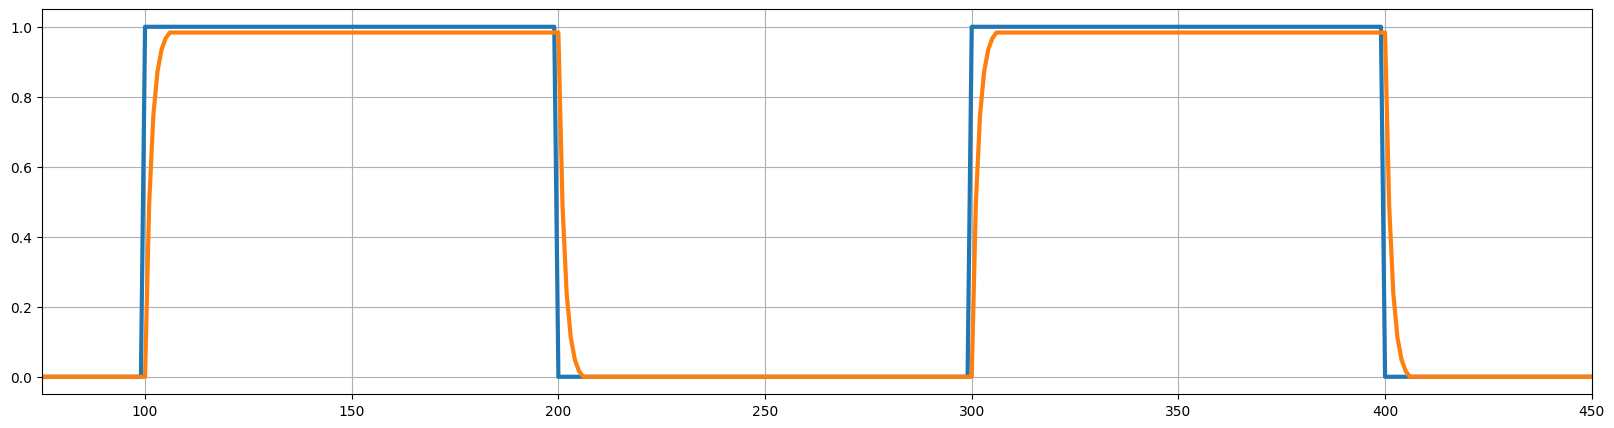

In [13]:
plt.figure(figsize=(20,5))
plt.plot(x, linewidth=3)
plt.plot(y_int, linewidth=3)
plt.xlim(75,450)
plt.grid(1)

In [16]:
f0 = 2340
fs = 10000
B = 115
omega_norm = 2*np.pi*f0/fs
alpha = np.pi*B/fs
res_a = 1
res_b = np.array([0, 2*np.exp(-alpha)*np.cos(omega_norm), -np.exp(-2*alpha)])
y_res = np.zeros(len(x))
for i in range(2,len(y_int)):
    y_res[i] = x[i]*res_a + y_res[i-1]*res_b[1] + y_res[i-2]*res_b[2]

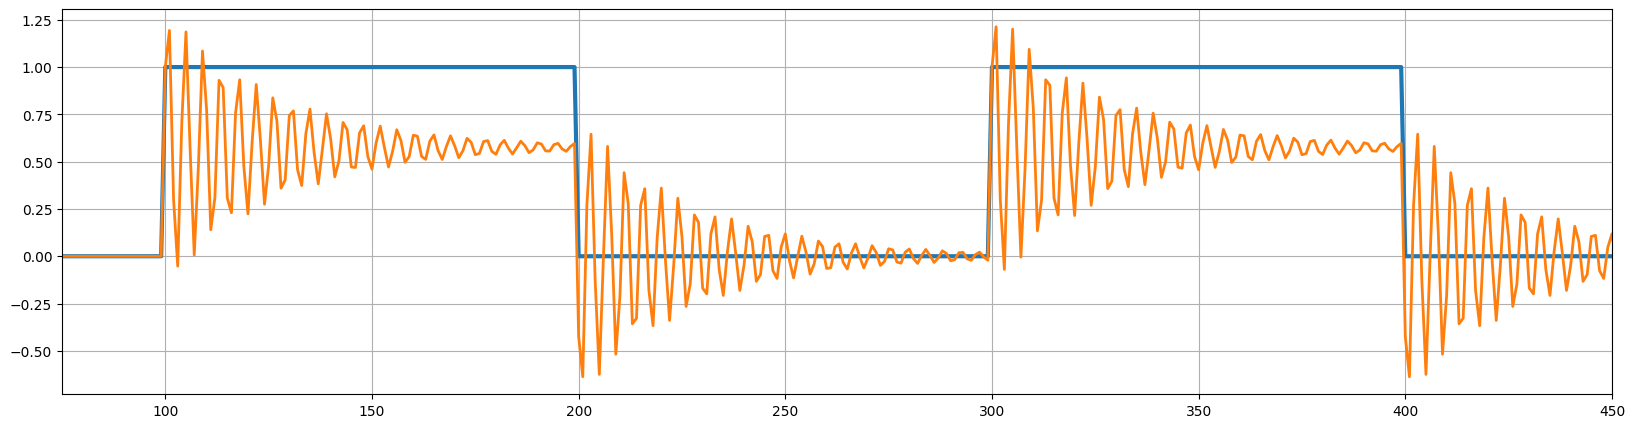

In [18]:
plt.figure(figsize=(20,5))
plt.plot(x, linewidth=3)
plt.plot(y_res, linewidth=2)
plt.xlim(75,450)
plt.grid(1)

In [ ]:
fc = 2340
f1 = 2*fc  # частота, накоторой затухание L
L = 13
N = np.ceil(np.log10(2*(np.pow(10, L/20))-1)/(2*np.log10(f1/fc)))
print(f"Порядок фильтра: {N}")


Порядок фильтра: 2.0
